# Convolutional Neural Networks

Organized by: Ethan Robert A. Casin

In this notebook, we'll learn about convolutional neural networks (CNNs) and how we can implement CNNs in PyTorch. CNNs are usually the steppping stone for ML practitioners into the world of computer vision.

Our objectives today are to:
1. Learn what convolution is
2. Understand some regularization methods for CNNs, such as max pooling and batch normalization.
3. Build a small CNN network

*Note: Content was derived from the CNN lecture of Christopher Monterola, PhD*

The following were used as additional source material for this lecture:
1. [Intuitive Guide to Convolution](https://betterexplained.com/articles/intuitive-convolution/)
2. [An Introduction to Convolutional Neural Networks (CNNs)](https://www.datacamp.com/tutorial/introduction-to-convolutional-neural-networks-cnns)

---

In [23]:
!pip install torchvision torchsummary Pillow --quiet

In [24]:
from typing import Union

import numpy as np
import matplotlib.pyplot as plt

import torch
import torchvision # For our MNIST dataset
from torch import nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
from torchvision.transforms import ToTensor

In [25]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using mps device


## Introduction

Convolutional neural networks, aka CNNs, are a family of models that were inspired by how the visual cortex of the human brain works when doing object recognition. 

As you know by now, a key indicator to know if your machine learning model is performing well is its ability to **extract salient (relevant) features** from the data you gave it. Neural networks are able to automatically learn features from raw data that are most useful for a task. It's for this reason that it's common to consider a neural network as a feature extraction engine, where the **early layers** (those that appear after the input layer) extract **low level features**.

Neural networks try to understand representations through salient features.



<figure align="center">
<img src="figures/visual-cortex.png" width="50%">
<figcaption>Figure 1. Correspondence of the human visual cortex to CNNs (source from <a href="https://www.researchgate.net/figure/llustration-of-the-corrispondence-between-the-areas-associated-with-the-primary-visual_fig7_317679065">here.</a>)</figcaption>
</figure>

CNNs construct a so-called **feature hierarchy** by combining low-level features in a layer-wise fashion to form high-level features. Examples of low-level features in images include edges and blobs that are extracted from the earlier layers. Layer, these are combined to form high-level features such as object shapes.

There are two important ideas to know about how CNNs function:

1. **Sparse-connectivity:** A single element in the feature map is connected to only a small patch of pixels. This is a different idea from connecting the whole input image as in the case of neural networks / perceptrons.

2. **Parameter-sharing:** The same weights are used for different patches of the input image.


As a direct consequence of these two ideas, the number of weights (parameters) in the network decreases dramatically. It makes sense that nearby pixels are probably more relevant to each other than pixels that are farther away. 

**Note:** This is often attributed to the *local receptive field* of a CNN, where CNNs inherently understand spatial relationships. This is pretty handy if you want to do geospatial analysis.


The first layers will learn like what is the line segment of the head, layer 2 will see the circle of the head, combine from layer 2 to get a person and then put it all through a neural network. In NN, this would be a multi-layer perceptron (which is an improvement of the perceptron). in the original form of a perceptron where you cant have multi-layers. A person was able to innovate to have a multi-layer perceptron.

is the model trying to op

Typically, CNNs are composed of several Convolutional (conv) layers and subsampling (also known as Pooling (P)) layers that are followed by one or more Fully Connected (FC) layers at the end. The fully connected layers are essentially a multilayer perceptron, where every input unit $i$ is connected to every output unit $j$ with weight $w_{ij}$(which we learned previously).



### Convolution

Now what drives all of this? 

A discrete convolution (or just convolution) is an important operation in CNN.

a cnn will take little sections for and then the bdcc will take the image as a whole

for the cnn, you have to optimize for the kernel


We have that a local receptive field is a spatially -aware model. 
It can understand locations and can understand physical locations. It is also depth-aware. It knows exactly that near things should be similar and farther away things are not similar. A model does not have a sense of orientation but it knows which things are near or not. This is what you call a local receptive field and says that if it is near, then it is also near.

For a person, we can augment data by rotating the picture or like slide them to the side. Like, you have the same dataset and augment it. 

#### Convolution in 1D

A discrete convolution for two one-dimensional vectors $x$ and $w$ is denoted by $y = x * w$, in which vector $x$ is our input (sometimes called *signal*) and $w$ is called the *filter or kernel*. A discrete convolution is mathematically defined as

\begin{equation*}
y = x * w = \sum_{k=-\infty}^{k=+\infty}x[i -k]w[k]
\end{equation*}

Here, the brackets $[\dots]$ are used to denote the indexing of the vector elements. The index $i$ runs through each element of the output vector $y$. There are two odd things in the preceding formula that needs to b"e clarified: $-\infty$ to $+\infty$ indices and the negative indexing for $x$.

The **first issue** where the **sum runs through indices from $−\infty$ to $+\infty$** seems odd mainly because in machine learning applications, we always deal with finite feature vectors. For example, if $x$ has 10 features with indices 0,1,2,…,8,9, then indices $−\infty:-1$ and $10 : +\infty$ are out of bounds for $x$. Therefore, to correctly compute the summation shown in the preceding formula, it is assumed that $x$ and $w$ are filled with zeros. This will result in an output vector $y$ that also has infinite size with lots of zeros as well. Since this is not useful in practical situations, $x$ is padded only with a
finite number of zeros.   

This process is called **zero-padding** or simply **padding**. Here, the number of zeros padded on each side is denoted by *p*. An example padding of a one-dimensional vector $x$ is shown in the following figure:

<figure align="center">
<img src="figures/convolve1.png" width="90%">
</figure>

Let's assume that the original input $\mathbf{x}$ and filter $\mathbf{w}$ have $n$ and $m$ elements, respectively, where $m \leq n$. Therefore, the padded vector $\mathbf{x}^p$  has size $n + 2p$. Then, the practical formula for computing a discrete convolution will change to the following:


\begin{equation}
\mathbf{y}= \mathbf{x} * \mathbf{w} \Rightarrow \mathbf{y}[i]= \sum_{k=0}^{k=m-1} \mathbf{x}^p [i+m-k] \mathbf{w}[k]
\end{equation}


Now that we have solved the infinite index issue, the second issue is indexing $x$ with $i + m - k$. The important point to notice here is that $x$ and $w$ are indexed in different directions in this summation. For this reason, we can flip one of those vectors, $x$ or $w$, after they are padded. Then, we can simply compute their dot product.    

Let's assume we flip the filter $w$ to get the rotated filter $w^r$ . Then, the dot product $x[i : i + m]$ $\cdot$ $w^r$ is computed to get one element $y[i]$, where $x[i : i + m]$ is a patch of $x$ with size $m$.

This operation is repeated like in a sliding window approach to get all the output elements. The following figure provides an example with $x = (3,2,1,7,1,2,5,4)$ and $w$ = ($\frac{1}{2}, \frac{3}{4}, 1, \frac{1}{4}$) so that the first three output elements are computed:

<figure align="center">
<img src="figures/convolve2.png" width="90%">
</figure>

You can see in the preceding example that the padding size is zero ($p = 0$). Notice that the rotated filter wr is shifted by two cells each time we shift. This shift is another hyperparameter of a convolution, the stride $s$. In this example, the **stride is two**, $s = 2$. Note that the stride has to be a positive number smaller than the size of the input vector $x$ (pause and answer why?). We'll talk more about padding and strides in the next section!

The bigger the image, you want to have a bigger stride so that you can have it fast. You would equally divide the image and one stride is just the equal segments.

#### Example 1: Counting medicines used per day

Let's assume that you have a list of daily patient intake counts given as $[1, 2, 3, 4, 5]$, where the first instance corresponds to the Monday count (value 1), next is the Tuesday count (value 2), etc.

Let's assume that all patients would receive the same dosage quantity for some medicine, say, $[2]$. If we want to know the number of dosages used for each day of the week, we simply do $[2] * [1, 2, 3, 4, 5] = [2, 4, 5, 8, 10]$.

But what if we have to give patients on their first day a dosage of 3, then 2 on their second, and 1 on their last? Then it becomes more complicated. 

This is where convolution becomes more handy. If we take these two lists as is, you'll still have a tricky time computing for what we need. The trick is to flip one of the lists we have. Say, for instance, that our dosages are fixed and we want to count the "incoming" patients per day. 

Let's see how we can do that in code.

In [26]:
dosages = [3, 2, 1]

# We'll be fliping this list
# It will result to [5, 4, 3, 2, 1] when doing the convolution
daily_patients = [1, 2, 3, 4, 5]

np.convolve(dosages, daily_patients)

array([ 3,  8, 14, 20, 26, 14,  5])

The resulting vector above is our dosage count per day until all of the patients have gone.

#### Example 2: Moving Average

Another way to think of a convolution is in the lens of time series. We can think of our kernel as a way to compute for the moving average of a time series. 

Suppose we have a random time series, and a $1\times 5$ kernel whose elements are all equal sum to 1. It's easy to see that each value in our kernel is $1/5 = 0.2$. We can then use the same convolution operation on our time series and see the result below. 

Time Series Length: (100,)
Convolution out: (104,)


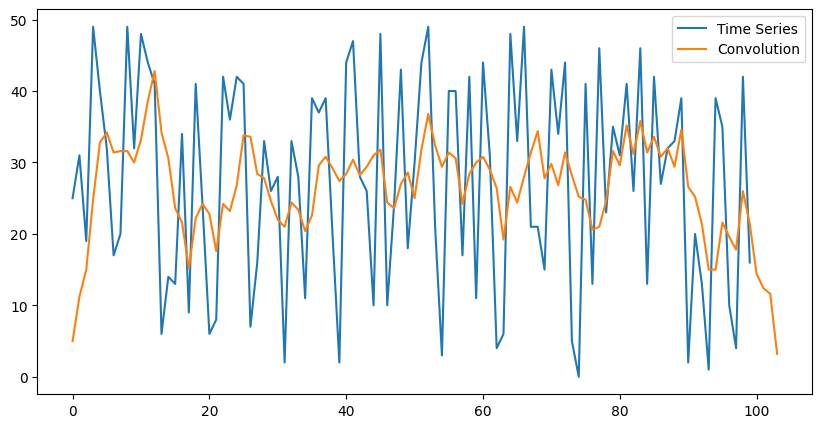

In [27]:
time_series = np.random.randint(0, 50, 100)
conv_kernel = [0.2] * 5

out = np.convolve(time_series, conv_kernel)

print(f"Time Series Length: {time_series.shape}")
print(f"Convolution out: {out.shape}")

plt.figure(figsize=(10, 5))
plt.plot(time_series, label="Time Series")
plt.plot(out, label="Convolution")
plt.legend()
plt.show()

---

**Question**: So far, can you come up with an equation to compute for the final length from our convolution?

---

You may be wondering why we always seem to generate more values than our input. The main reason for that is the *padding*.

### Different types of padding in convolution


There are three modes of padding that are commonly used in practice: **full**, **same**, and **valid**:

• In the **full mode**, the padding parameter $p$ is set to $p = m - 1$. Full padding increases the dimensions of the output; thus, it is rarely used in convolutional neural network architectures. An increasing dimension has problems with control of architectures and generalization (as it tends to overfit).

• **Same padding** is usually used if you want to have the size of the output ($\mathbf{y}$) the same as the input vector $\mathbf{x}$. In this case, the padding parameter $p$ is computed according to the filter size, along with the requirement that the input size and output size are the same.

• Finally, computing a convolution in the **valid mode** refers to the case where $p = 0$ (no padding).

The following figure illustrates the three different padding modes for a simple $5 \times 5$ pixel input with a kernel size of $3 \times 3$ and a stride of $1$:

<img width="807" alt="different_padding" src="https://user-images.githubusercontent.com/25600601/134187465-1f160b8d-cab8-4987-83fa-4a59d965f922.png">

**IMPORTANT NOTE**: The most commonly used padding mode in convolutional neural networks is **same padding**. One of its advantages over the other padding modes is that same padding preserves the height and width of the input images or tensors, which makes designing a network architecture more convenient.  

One big disadvantage of the valid padding versus full and same padding, for example, is that the volume of the tensors would decrease substantially in neural networks with many layers, which can be detrimental to the network performance.

In practice, it is recommended that you preserve the spatial size using same padding for the convolutional layers and  decrease the spatial size via pooling layers instead. As for the full padding, its size results in an output larger than the input size. Full padding is usually used in signal processing applications where it is important to minimize  boundary effects. **However, in deep learning context, boundary effect is not usually an issue**, so we rarely see full padding.


**Computing for the size of the convolution output**

The output size of a convolution is determined by the total  number of times that we shift the filter  $w$  along the input vector.Again, if the input vector $x$ has size
$n$ and the filter  $w$ is of size $m$. Then, the size of the output resulting from  $x *  w$  with padding $p$ and stride $s$ is determined as follows:

\begin{equation}
o=\left\lfloor\frac{n + 2p - m}{s}\right\rfloor + 1
\end{equation}

Here, the floor ($\lfloor \dots \rfloor$) operation returns the largest integer that is equal or smaller to the input, e.g. $\lfloor 1.43\rfloor$ =1

### Convolution in 2D

The concepts you learned in the previous sections are easily extendible to two dimensions. When we deal with two dimensional input, such as a matrix $\mathbf{X}_{n1×n2}$ and the filter matrix $\mathbf{W}_{m1×m2}$, where $m_1 \leq n_1$ and $m_2 \leq n_2$ , then the matrix $\mathbf{Y}$ = $\mathbf{X} * \mathbf{W}$ is the result of 2D convolution of $\mathbf{X}$ with $\mathbf{W}$. This is mathematically defined as follows:


\begin{equation}
\mathbf{Y}= \mathbf{X} * \mathbf{W} \Rightarrow \mathbf{Y}[i, j]= \sum_{k_1=-\infty}^{k_2=\infty}\sum_{k_2=-\infty}^{\infty} \mathbf{X} [i-k_1, j-k_2] \mathbf{W}[k_1, k_2]
\end{equation}

Notice that if you omit one of the dimensions, the remaining formula is exactly the same as the one we used previously to compute the convolution in 1D. In fact, all the previously mentioned techniques, such as zero-padding, rotating the filter matrix, and the use of strides, are also applicable to 2D convolutions, provided that they are extended to both the dimensions independently. The following example illustrates the computation of a 2D convolution between an input matrix $\mathbf{X}_{3×3}$, a kernel matrix $\mathbf{W}_{3×3}$, padding $p = (1, 1)$, and stride $s = (2, 2)$. According to the specified padding, one layer of zeros are padded on each side of the input matrix, which results in the padded matrix $\mathbf{X}_{5×5}^{padded}$, as follows:

<img width="746" alt="padded_2d" src="https://user-images.githubusercontent.com/25600601/134188176-c6a412b6-c6bd-49a4-bbdd-508b285e0882.png">

With the preceding filter, the rotated filter will be:

<img width="373" alt="Wrotated" src="https://user-images.githubusercontent.com/25600601/134188347-20df516d-0292-430a-91d5-bcc9eebc366e.png">

Note that this rotation is not the same as the transpose matrix. To get the rotated filter in NumPy, we can write W_rot=W[::-1,::-1]. Next, we can shift the rotated filter matrix along the padded input matrix $\mathbf{X}$ padded like a sliding window and compute the sum of the element-wise product, which is denoted by the dot operator in the
following figure:

<img width="900" alt="2d_convolution" src="https://user-images.githubusercontent.com/25600601/134188450-7da6a7f4-cea5-4b0d-80cd-34b56d3804ee.png">

The result will be the $2 \times 2$ matrix $\mathbf{Y}$.    



---
#### Activity: Exploring different kernels

For this activity, try to use different kernels and see its effects on the image below. What do you notice?

Here are some filters for you to explore for your reference:
https://en.wikipedia.org/wiki/Kernel_(image_processing)

![Convolution_Image](https://user-images.githubusercontent.com/25600601/134189184-b6f76ae9-0445-4e26-bd72-e2200cd36dee.png)


t-distr is supposed to be sharper compared to the gaussian blur

In [28]:
from PIL import Image
import scipy
from skimage import exposure

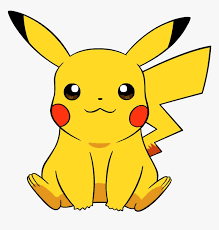

In [29]:
img_path = "figures/pikachu.png"
img = Image.open(img_path)

display(img)

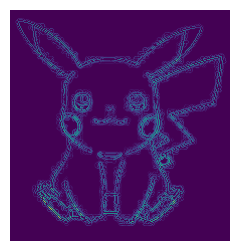

In [30]:
# You can change this

kernel = np.array(
    [
        [0, 1, 0],
        [1, -4, 1],
        [0, 1, 0]
    ]
)

convolved_img = scipy.signal.convolve2d(img, kernel, 'same')

# Adjust the contrast of the filtered image by applying Histogram Equalization
convolved_img_equalized = exposure.equalize_adapthist(
    convolved_img/np.max(np.abs(convolved_img)), clip_limit=0.03
)

fig = plt.figure(figsize=(3,3))

plt.imshow(convolved_img_equalized)
plt.axis('off')
plt.show()


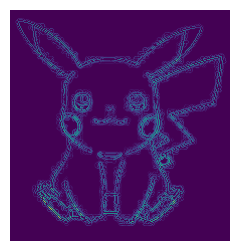

In [31]:
# You can change this

kernel = np.array(
    [
        [0, 1, 0],
        [1, -4, 1],
        [0, 1, 0]
    ]
)

convolved_img = scipy.signal.convolve2d(convolved_img_equalized, kernel, 'same')

# Adjust the contrast of the filtered image by applying Histogram Equalization
convolved_img_equalized_2 = exposure.equalize_adapthist(
    convolved_img/np.max(np.abs(convolved_img)), clip_limit=0.03
)

fig = plt.figure(figsize=(3,3))

plt.imshow(convolved_img_equalized)
plt.axis('off')
plt.show()


## Subsampling or Pooling


Subsampling is typically applied in two forms of pooling operations in convolutional neural networks: **max-pooling** and **mean-pooling** (also known as **average-pooling**). Here, max-pooling takes the maximum value from a neighborhood of pixels, and mean-pooling computes their average. The pooling layer is usually denoted by $\mathbf{P}_{n1×n2}$. Here, the subscript determines the size of the neighborhood (the number of adjacent pixels in each dimension), where the max or mean operation is performed. We refer to such a neighborhood as the pooling size.


The advantage of pooling is two-fold:

• **Pooling (max-pooling)** introduces some sort of local invariance. This means that small changes in a local neighborhood do not change the result of max-pooling. Therefore, it helps **generate features that are more robust to noise** in the input data. See the following example that shows max-pooling of two different input matrices $\mathbf{X}_1$ and $\mathbf{X}_2$ results in the same output.     

<img width="911" alt="max_pooling" src="https://user-images.githubusercontent.com/25600601/134189420-0be5f32b-efc9-4125-911d-beaf2917491d.png">


• **Pooling** decreases the size of features, which results in higher computational efficiency. Furthermore, reducing the number of features may reduce the degree of overfitting as well.

You do max polling to get the most significant signal in that area.


### Batch Normalization

Before we begin building our model, let's try to understand one last method usually done with CNNs. 

**Batch Normalization** is a normalization technique used to make training faster and making them more stable -- avoiding the so-called [internal covariate shift](https://www.geeksforgeeks.org/deep-learning/internal-covariant-shift-problem-in-deep-learning/). It works as the name implies: it normalizes the data.

It works by getting the mean and standard deviation of each mini-batch and then adjusts the mini batch values so that they have a similar range. This ensures that the inputs to each layer of the network is in a stable range, even if the outputs of earlier layers change during training.

Because of this, it makes training faster and more stable. Another benefit of batch normalization is that it tends to act as a slight regularization technique that reduces the need to include dropouts in the network.

BATCH NORMALIZATION HELPS STABILIZE, GIVE SOME SLIGHT REGULARIZATION (CNNS DONT NEED MORE DROPOUTS)

SOME TREAT BATCH NORM AS DRO POUT STET TO REGULARIZE CNN

## The AlexNet Architecture

Image Net - made by Fei Fei Li

It's time to build our own network. To have more guidance and practice, let's build out a smaller version of the [AlexNet](https://en.wikipedia.org/wiki/AlexNet).

It deepstarted modern architecture. This is just 8 layers.

In [32]:
from torchsummary import summary
from torch.utils.data import Subset


<figure align="center">
<img src="figures/alexnet2.png" width="70%">
</figure>

**Downloading MNIST digit data**

In [34]:
# Download MNIST data

train_data = torchvision.datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

subset_size = 1000
indices = torch.randperm(len(train_data))[:subset_size]
train_small = Subset(train_data, indices)

test_data = torchvision.datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

# Create a validation set

train_size = int(0.8 * len(train_small))  
val_size = len(train_small) - train_size

train_set, val_set = random_split(train_small, [train_size, val_size])

# By default, our datasets are now tensors
# so we just need to pass them to our dataloaders
batch_size = 64

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:14<00:00, 677kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 118kB/s]
100%|██████████| 1.65M/1.65M [00:02<00:00, 650kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.35MB/s]


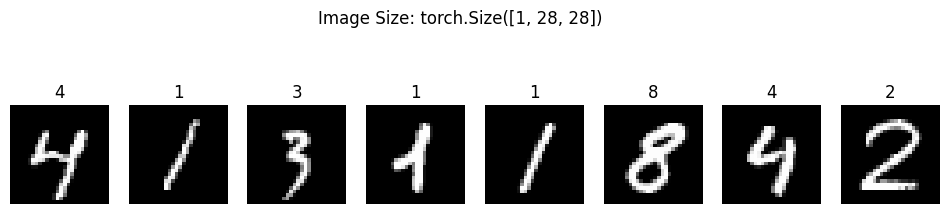

In [35]:
# Let's print one batch of data

images, labels = next(iter(train_loader))

# show first 8 examples
fig, axes = plt.subplots(1, 8, figsize=(12, 3))
for i in range(8):
    axes[i].imshow(images[i].squeeze(), cmap="gray")
    axes[i].set_title(labels[i].item())
    axes[i].axis("off")
plt.suptitle(f"Image Size: {images[0].size()}")
plt.show()

#### Activity: Modify the AlexNet

Try to improve this model by either getting a higher accuracy or faster training time. Feel free to include BatchNormalization, but ensure that the architecture is still faithful to the diagram above.

In [ ]:
class BabyAlex(nn.Module):

    def __init__(
        self,
        stride: int = 1,
        n_classes: int = 10,
    ):
        super().__init__()
        self.processing = nn.Sequential(
            # Block 1: 1x28x28 -> 16x28x28 -> 16x14x14
            nn.Conv2d(1, 16, kernel_size=5, stride=1, padding=2),  # preserves 28x28
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),                 # 14x14

            # Block 2: 16x14x14 -> 32x14x14 -> 32x7x7
            # 16 is input channels and 32 is how many you are sppitting
            nn.Conv2d(16, 32, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),                 # 7x7

            # Block 3: 32x7x7 -> 64x7x7
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU()
        )

        self.classifier = nn.Sequential(
                nn.Linear(64 * 7 * 7, 256),
                nn.ReLU(),
                nn.Dropout(0.5),
                nn.Linear(256, 256),
                nn.ReLU(),
                nn.Dropout(0.5),
                nn.Linear(256, n_classes),
                nn.Softmax()
        )

    def forward(self, X):
        x = self.processing(X)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [37]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=100, show_grad=False):
    
    train_losses = []
    val_losses = []
    
    n_trainloader = len(train_loader)
    n_valloader = len(val_loader)
    
    # Model training
    for epoch in range(epochs):
        model.train()
        running_loss = 0
        
        for X_batch, y_batch in train_loader:
            # Define where to put the data
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
                
            # Print gradients
            if show_grad:
                for name, param in model.named_parameters():
                    if param.grad is not None:
                        print(f"{name}: grad_norm = {param.grad.norm().item():.6f}")
            optimizer.step()
            running_loss += loss.item()
    
        train_losses.append(running_loss / n_trainloader)
    
        # Validation
        model.eval()
        with torch.no_grad():
            val_loss = 0
            for X_val, y_val in val_loader:
                # Define where to put the data

                X_val = X_val.to(device)
                y_val = y_val.to(device)
                
                preds = model(X_val)
                # no need to do backpropagation for inference
                vloss = criterion(preds, y_val)
                val_loss += vloss.item()
            val_losses.append(val_loss / n_valloader)
    return train_losses, val_losses

In [38]:
learning_rate = 0.001
model = BabyAlex()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

summary(model, (1, 28, 28))
model = model.to(device) # had to put this here so that the summary won't raise an error

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 28, 28]             416
              ReLU-2           [-1, 16, 28, 28]               0
         MaxPool2d-3           [-1, 16, 14, 14]               0
            Conv2d-4           [-1, 32, 14, 14]          12,832
              ReLU-5           [-1, 32, 14, 14]               0
         MaxPool2d-6             [-1, 32, 7, 7]               0
            Conv2d-7             [-1, 64, 7, 7]          18,496
              ReLU-8             [-1, 64, 7, 7]               0
            Linear-9                  [-1, 256]         803,072
             ReLU-10                  [-1, 256]               0
          Dropout-11                  [-1, 256]               0
           Linear-12                  [-1, 256]          65,792
             ReLU-13                  [-1, 256]               0
          Dropout-14                  [

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/nn/modules/module.py:1881: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return inner()


conv2d is 16 channels (a channel is the width of the image, in an image, how many channels are there? 3 because of RGB). When you do a convolution, you will get 16 channels from the 16 neural feature maps with a kernel of 5 by 5. Conv1 will be 5 times 5 times 16 + 16 with 16 coming from the bias. 

MaxPool2d-3 is 0 because there are no parameters.

Conv2d-4 is 25 times 32 times 16 + 23. 32 is the output of the feature map with 16 from the previous layer and 25 is the kernel

Conv2d-7 is 3 times 3 (kernel size) time 32 channels from the input times 64 (output of the new channels) + 64 (bias of output)


Linear-15 began with 10 output with 256 inputs + 10 of the bias


In [39]:
train_loss, val_loss = train_model(
    model,
    train_loader,
    val_loader, 
    criterion,
    optimizer, 
    device,
    show_grad=False,
)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


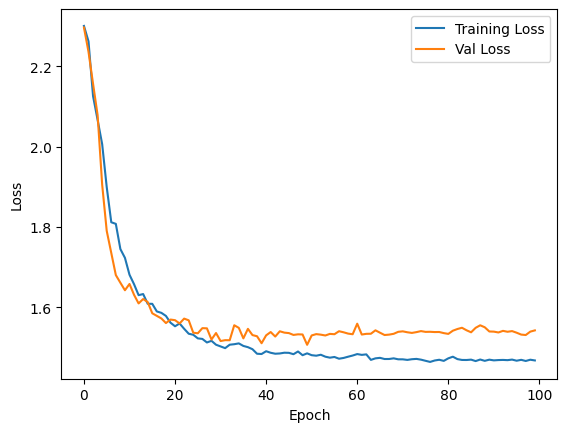

In [40]:
plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [41]:
def show_batch(images, labels, preds, n=16):
    plt.figure(figsize=(12, 8))
    for i in range(n):
        plt.subplot(4, 4, i+1)
        plt.imshow(images[i].cpu().squeeze(), cmap='gray')
        plt.title(f"T:{labels[i].item()} P:{preds[i].item()}")
        plt.axis('off')
    plt.show()

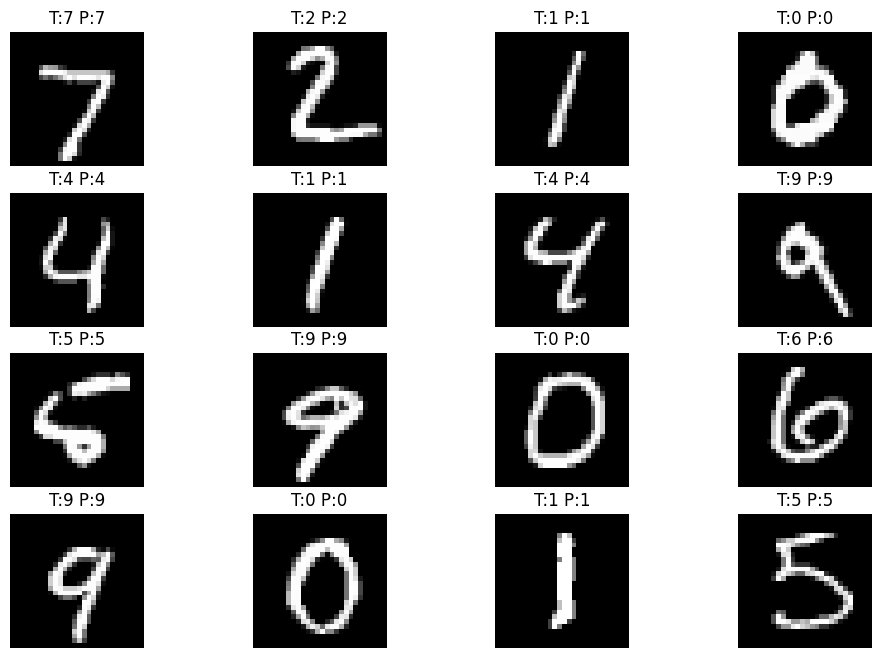

In [42]:
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        preds = logits.argmax(dim=1)

        show_batch(images, labels, preds, n=16)
        break   # show only first batch — remove to show all